# Introduction au ML — Séance 6 (TP)
## Classifier pour de vrai : régression logistique, seuil et métriques honnêtes

**Dr. El Hadji Bassirou TOURÉ** · DMI · FST · UCAD

***

L'arbre de la Séance 3 et la régression linéaire de la Séance 5 ont tous deux échoué sur
le **paludisme** ($11{,}8\,\%$ de positifs) — du moins selon l'accuracy. Ce TP reconstruit
**à la main** : la sigmoïde, la log-loss, la matrice de confusion, precision/recall/F1, le
balayage du seuil, la courbe ROC point par point et l'AUC par comptage de paires — puis
confronte chaque calcul à scikit-learn, et réhabilite le « modèle inutile ».

**Durée estimée : 1h30.** Exécuter les cellules dans l'ordre, de haut en bas.

## Partie 0 — Mise en place

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 3)
print("Outils prêts. NumPy", np.__version__, "· pandas", pd.__version__)

Outils prêts. NumPy 2.4.4 · pandas 3.0.2


In [2]:
# Ne pas modifier cette cellule : générateur officiel DataSANTÉ-221
def generate_datasante221(n=10_000, seed=221):
    rng = np.random.default_rng(seed)
    age = np.clip(rng.gamma(2.5, 14, n), 5, 85).round(0).astype(int)
    glycemie = np.clip(rng.normal(5.5 + 0.05*age, 1.8), 3.0, 18.0).round(1)
    hemoglobine = np.clip(rng.normal(12.5 - 0.02*age, 1.5), 6.0, 17.0).round(1)
    fievre = np.clip(rng.normal(37.5, 0.9, n), 36.0, 41.5).round(1)
    saison = rng.choice([0, 1], size=n, p=[0.55, 0.45])
    duree = (1.0 + 0.05*age + 0.6*glycemie - 0.3*hemoglobine
             + 1.5*saison + rng.normal(0, 1.8, n)).clip(0.5, 30).round(1)
    proba_palu = 1/(1+np.exp(-(-3 + 1.5*saison + 0.8*(fievre>38.5))))
    palu = (rng.uniform(0,1,n) < proba_palu).astype(int)
    return pd.DataFrame({'age':age,'glycemie':glycemie,'hemoglobine':hemoglobine,
                         'fievre':fievre,'saison':saison,
                         'duree_hospit_j':duree,'paludisme':palu})

df = generate_datasante221()
print("dimensions :", df.shape)

dimensions : (10000, 7)


In [3]:
# La cible du jour : le paludisme — une classe rare
print(df["paludisme"].value_counts())
print("\npart de positifs :", round(df["paludisme"].mean(), 3))
print("baseline « personne n'a le paludisme » :", round(1 - df["paludisme"].mean(), 4))

paludisme
0    8824
1    1176
Name: count, dtype: int64

part de positifs : 0.118
baseline « personne n'a le paludisme » : 0.8824


**Lecture.** $1\,176$ malades sur $10\,000$ : prédire « jamais malade » garantit déjà
$88{,}2\,\%$ d'accuracy. C'est la barre — et le piège — de toute la séance.

## Partie 1 — La sigmoïde : du score à la probabilité

La régression logistique garde le score linéaire $z = b + \mathbf{w}\cdot\mathbf{x}$ de la
Séance 5 et le passe dans la **sigmoïde** $\sigma(z) = 1/(1+e^{-z})$, qui l'écrase
dans $]0,1[$.

In [4]:
# La sigmoïde en une ligne — et ses valeurs remarquables
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

for z in [-4, -2, 0, 2, 4]:
    print(f"sigma({z:+d}) = {sigmoide(z):.4f}")

sigma(-4) = 0.0180
sigma(-2) = 0.1192
sigma(+0) = 0.5000
sigma(+2) = 0.8808
sigma(+4) = 0.9820


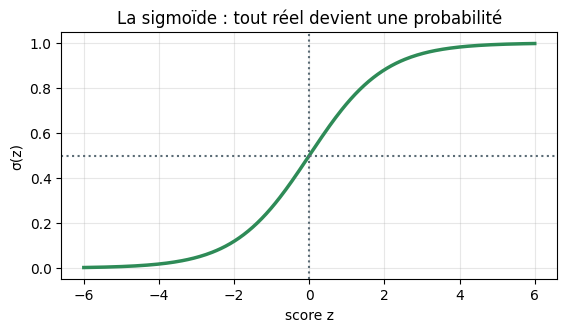

In [5]:
# La courbe complète
z = np.linspace(-6, 6, 300)
plt.figure(figsize=(6.4, 3.2))
plt.plot(z, sigmoide(z), color="#2E8B57", lw=2.5)
plt.axhline(0.5, color="#5A6B75", ls=":"); plt.axvline(0, color="#5A6B75", ls=":")
plt.xlabel("score z"); plt.ylabel("σ(z)")
plt.title("La sigmoïde : tout réel devient une probabilité"); plt.grid(alpha=0.3)
plt.show()

**Lecture.** $\sigma(0) = 0{,}5$ (l'indécision), $\sigma(-z) = 1 - \sigma(z)$ (la
symétrie), et quatre unités de score suffisent pour passer de $0{,}12$ à $0{,}88$. La sortie
ne quitte jamais $]0,1[$ — exactement ce qui manquait à la droite nue de la Séance 5.

**Exercice.** Calculer $\sigma(1)$ et $\sigma(-1)$ avec la fonction `sigmoide`, et
vérifier numériquement que leur somme vaut $1$.

In [ ]:
# sigma(1), sigma(-1), et la vérification de la symétrie

## Partie 2 — La régression logistique sur le paludisme

Le protocole habituel : split **stratifié** (la classe est rare, chaque moitié doit en
garder la même part), Pipeline avec standardisation (la log-loss s'apprend par descente
de gradient — Séance 5), puis `LogisticRegression`.

In [7]:
# Split stratifié + Pipeline standardisation -> logistique
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

colonnes = ["age", "glycemie", "hemoglobine", "fievre", "saison"]
X = df[colonnes]
y = df["paludisme"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)
modele = make_pipeline(StandardScaler(),
                       LogisticRegression(max_iter=1000, random_state=0))
modele.fit(X_train, y_train)
print("test :", len(y_test), "patients, dont", int(y_test.sum()), "malades")

test : 2000 patients, dont 235 malades


In [8]:
# Deux sorties bien distinctes : la probabilité, puis la décision
proba = modele.predict_proba(X_test)[:, 1]
y_pred = modele.predict(X_test)           # seuil 0,5 implicite
print("probabilités : min =", proba.min().round(3), "· max =", proba.max().round(3))
print("positifs prédits au seuil 0,5 :", int(y_pred.sum()), "sur", len(y_pred))

probabilités : min = 0.034 · max = 0.286
positifs prédits au seuil 0,5 : 0 sur 2000


In [9]:
# Les poids appris (variables standardisées : comparables entre eux)
logreg = modele.named_steps["logisticregression"]
print(pd.Series(logreg.coef_[0], index=colonnes).round(3))
print("intercept :", round(logreg.intercept_[0], 3))

age            0.020
glycemie      -0.103
hemoglobine    0.044
fievre         0.122
saison         0.750
dtype: float64
intercept : -2.238


**Lecture.** Maximum des probabilités : $0{,}286$ — au seuil $0{,}5$, **zéro alerte**.
Les poids racontent pourquoi : seule la saison pèse vraiment ($+0{,}75$), la fièvre un peu
($+0{,}12$), et l'intercept très négatif ($-2{,}24$) encode la rareté de la maladie. Le
modèle est prudent par construction — reste à savoir s'il est *informatif*.

In [10]:
# Le score z et la probabilité d'une patiente, terme à terme — à la main
x0_brut = X_test.iloc[[0]]
x0_std = modele.named_steps["standardscaler"].transform(x0_brut)[0]
z0 = logreg.intercept_[0] + np.dot(logreg.coef_[0], x0_std)
print("patiente :", x0_brut.values[0], "| réalité y =", y_test.iloc[0])
print("x standardisé :", x0_std.round(3))
print("z =", round(z0, 3), "->  sigma(z) =", round(sigmoide(z0), 3))
assert np.isclose(sigmoide(z0), modele.predict_proba(x0_brut)[0, 1])
print("identique à predict_proba — vérifié.")

patiente : [31.   3.3 14.  38.3  1. ] | réalité y = 1
x standardisé : [-0.17  -1.949  1.403  0.895  1.123]
z = -1.027 ->  sigma(z) = 0.264
identique à predict_proba — vérifié.


**Lecture.** Cette patiente *a* le paludisme ($y = 1$) ; le modèle lui donne
$\hat p = 0{,}264$ — sa plus forte conviction ou presque, et pourtant très en dessous du
seuil $0{,}5$. Retenir ce cas : il illustre tout le problème du seuil par défaut.

## Partie 3 — La log-loss, à la main

Le critère d'entraînement de la logistique : chaque prédiction paie
$-\ln \hat p$ si $y = 1$, $-\ln(1-\hat p)$ si $y = 0$. La confiance mal placée coûte
très cher.

In [11]:
# Quatre paris chiffrés
for p_hat, y_vrai in [(0.9, 1), (0.5, 1), (0.9, 0), (0.99, 0)]:
    perte = -(y_vrai*np.log(p_hat) + (1 - y_vrai)*np.log(1 - p_hat))
    print(f"p_hat = {p_hat:4} · y = {y_vrai} : perte = {perte:.3f}")

p_hat =  0.9 · y = 1 : perte = 0.105
p_hat =  0.5 · y = 1 : perte = 0.693
p_hat =  0.9 · y = 0 : perte = 2.303
p_hat = 0.99 · y = 0 : perte = 4.605


In [12]:
# La log-loss moyenne du modèle sur le test — à la main, puis sklearn
from sklearn.metrics import log_loss

perte_main = -np.mean(y_test*np.log(proba) + (1 - y_test)*np.log(1 - proba))
print("log-loss à la main :", round(perte_main, 4))
print("log_loss sklearn   :", round(log_loss(y_test, proba), 4))
assert np.isclose(perte_main, log_loss(y_test, proba))

log-loss à la main : 0.3285
log_loss sklearn   : 0.3285


**Exercice.** Calculer la perte d'un modèle qui prédit $\hat p = 0{,}8$ pour un
patient réellement négatif ($y = 0$), puis pour un patient positif ($y = 1$). Le rapport
entre les deux pertes est d'environ $7$.

In [ ]:
# Les deux pertes pour p_hat = 0,8, et leur rapport

## Partie 4 — La matrice de confusion, à la main

Le jouet de la séance : six patients, leurs probabilités prédites, la réalité. Quatre
cases : TP (malade alerté), FN (malade manqué), FP (fausse alerte), TN (sain rassuré).

In [14]:
# Le jouet des six patients
p6 = np.array([0.9, 0.75, 0.6, 0.4, 0.3, 0.1])
y6 = np.array([1,   1,    0,   1,   0,   0])
decision = (p6 >= 0.5).astype(int)
print(pd.DataFrame({"p_hat": p6, "réalité": y6, "décision (s=0,5)": decision},
                   index=[f"patient {i}" for i in range(1, 7)]))

           p_hat  réalité  décision (s=0,5)
patient 1   0.90        1                 1
patient 2   0.75        1                 1
patient 3   0.60        0                 1
patient 4   0.40        1                 0
patient 5   0.30        0                 0
patient 6   0.10        0                 0


In [15]:
# Les quatre cases, comptées à la main avec des masques booléens
TP = int(((decision == 1) & (y6 == 1)).sum())
FP = int(((decision == 1) & (y6 == 0)).sum())
FN = int(((decision == 0) & (y6 == 1)).sum())
TN = int(((decision == 0) & (y6 == 0)).sum())
print(f"TP={TP}  FP={FP}  FN={FN}  TN={TN}")

from sklearn.metrics import confusion_matrix
print("\nconfusion_matrix (lignes = réalité 0 puis 1) :\n",
      confusion_matrix(y6, decision))

TP=2  FP=1  FN=1  TN=2

confusion_matrix (lignes = réalité 0 puis 1) :
 [[2 1]
 [1 2]]


**Lecture.** Attention à la convention : `confusion_matrix` range les classes en ordre
croissant, donc **TN en haut à gauche** et TP en bas à droite. Les quatre comptes à la main
et la matrice sklearn coïncident : TP $=2$, FP $=1$, FN $=1$, TN $=2$.

In [16]:
# Accuracy, precision, recall, F1 — à la main puis sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc  = (TP + TN) / 6
prec = TP / (TP + FP)
rec  = TP / (TP + FN)
f1   = 2*prec*rec / (prec + rec)
print(f"à la main : acc={acc:.3f}  precision={prec:.3f}  recall={rec:.3f}  F1={f1:.3f}")
print(f"sklearn   : acc={accuracy_score(y6, decision):.3f}  "
      f"precision={precision_score(y6, decision):.3f}  "
      f"recall={recall_score(y6, decision):.3f}  F1={f1_score(y6, decision):.3f}")

à la main : acc=0.667  precision=0.667  recall=0.667  F1=0.667
sklearn   : acc=0.667  precision=0.667  recall=0.667  F1=0.667


**Exercice.** Sur $100$ patients : TP $= 8$, FP $= 2$, FN $= 4$, TN $= 86$. Calculer
les quatre métriques à la main. Les résultats attendus sont $0{,}94$ / $0{,}80$ / $0{,}667$ /
$0{,}727$ — noter le contraste entre l'accuracy et le recall.

In [ ]:
# Les quatre métriques pour TP=8, FP=2, FN=4, TN=86

## Partie 5 — Le seuil : un curseur, pas une constante

Retour au paludisme. Le modèle produit des probabilités ; la décision dépend du seuil —
et le $0{,}5$ par défaut est ici catastrophique.

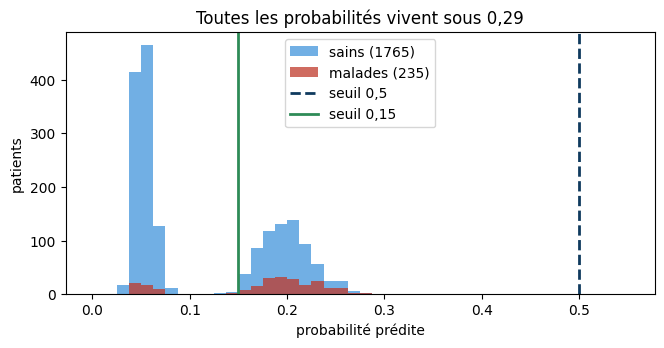

In [18]:
# L'histogramme qui explique tout : les probabilités, classe par classe
plt.figure(figsize=(7.6, 3.4))
bins = np.linspace(0, 0.55, 45)
plt.hist(proba[y_test == 0], bins=bins, color="#2585D6", alpha=0.65, label="sains (1765)")
plt.hist(proba[y_test == 1], bins=bins, color="#C0392B", alpha=0.75, label="malades (235)")
plt.axvline(0.5, color="#0F3A5E", ls="--", lw=2, label="seuil 0,5")
plt.axvline(0.15, color="#2E8B57", lw=2, label="seuil 0,15")
plt.xlabel("probabilité prédite"); plt.ylabel("patients"); plt.legend()
plt.title("Toutes les probabilités vivent sous 0,29")
plt.show()

In [19]:
# Le balayage du seuil, chiffré
def bilan_au_seuil(s):
    yh = (proba >= s).astype(int)
    tp = int(((yh == 1) & (y_test == 1)).sum())
    fp = int(((yh == 1) & (y_test == 0)).sum())
    fn = int(((yh == 0) & (y_test == 1)).sum())
    prec = tp/(tp + fp) if tp + fp else float("nan")
    return {"seuil": s, "TP": tp, "FP": fp, "FN": fn,
            "precision": round(prec, 3), "recall": round(tp/(tp + fn), 3),
            "accuracy": round(accuracy_score(y_test, yh), 4)}

pd.DataFrame([bilan_au_seuil(s) for s in [0.5, 0.3, 0.2, 0.15, 0.1]])

,seuil,TP,FP,FN,precision,recall,accuracy
0,0.50,0,0,235,NaN,0.000,0.882
1,0.30,0,0,235,NaN,0.000,0.882
2,0.20,100,348,135,0.223,0.426,0.758
3,0.15,184,720,51,0.204,0.783,0.615
4,0.10,187,727,48,0.205,0.796,0.613


**Lecture.** Au seuil $0{,}5$ (et même $0{,}3$) : zéro alerte, recall nul, accuracy
$= 0{,}8825 =$ la baseline — le modèle *semble* inutile. À $0{,}15$ : $184$ malades sur $235$
retrouvés (recall $0{,}783$), au prix de $720$ fausses alertes et d'une accuracy qui
*chute* à $0{,}61$. Si la mission est « ne rien laisser circuler », le « pire » modèle au
sens de l'accuracy est le meilleur au sens de la mission. Aucun paramètre n'a été
réentraîné : seul le curseur a bougé.

**Exercice.** À l'aide de `bilan_au_seuil`, trouver un seuil qui donne un recall
d'au moins $0{,}60$ avec la meilleure precision possible (essayer quelques valeurs entre
$0{,}15$ et $0{,}20$).

In [ ]:
# Chercher un seuil : recall >= 0,60 avec la meilleure precision

## Partie 6 — La courbe ROC, construite à la main

Juger *tous* les seuils à la fois : trier les patients par probabilité décroissante, puis
descendre le curseur — chaque **positif fait monter** la courbe (TPR), chaque **négatif la
pousse à droite** (FPR).

In [21]:
# Le mécanisme sur le jouet : tri, puis cumuls
ordre = np.argsort(-p6)                  # tri par probabilité décroissante
y_trie = y6[ordre]
print("réalités triées par p_hat décroissante :", y_trie)

P, N = y6.sum(), (1 - y6).sum()
TPR = np.concatenate([[0], np.cumsum(y_trie) / P])        # un positif -> monter
FPR = np.concatenate([[0], np.cumsum(1 - y_trie) / N])    # un négatif -> à droite
print("TPR :", TPR.round(3))
print("FPR :", FPR.round(3))

réalités triées par p_hat décroissante : [1 1 0 1 0 0]
TPR : [0.    0.333 0.667 0.667 1.    1.    1.   ]
FPR : [0.    0.    0.    0.333 0.333 0.667 1.   ]


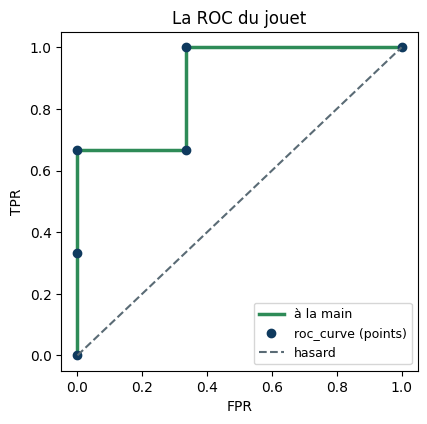

In [22]:
# Vérification contre roc_curve, puis le dessin
from sklearn.metrics import roc_curve, roc_auc_score

fpr_sk, tpr_sk, seuils_sk = roc_curve(y6, p6)
plt.figure(figsize=(4.6, 4.4))
plt.step(FPR, TPR, where="post", color="#2E8B57", lw=2.5, label="à la main")
plt.plot(fpr_sk, tpr_sk, "o", color="#0F3A5E", ms=6, label="roc_curve (points)")
plt.plot([0, 1], [0, 1], ls="--", color="#5A6B75", label="hasard")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(fontsize=9)
plt.title("La ROC du jouet"); plt.show()

In [23]:
# L'AUC par comptage de paires : la définition rendue concrète
paires_total, paires_bien = 0, 0
for i in range(6):
    for j in range(6):
        if y6[i] == 1 and y6[j] == 0:          # une paire (positif, négatif)
            paires_total += 1
            if p6[i] > p6[j]:                  # le positif est-il classé au-dessus ?
                paires_bien += 1
print(f"paires bien ordonnées : {paires_bien}/{paires_total} = {paires_bien/paires_total:.4f}")
print("roc_auc_score :", round(roc_auc_score(y6, p6), 4))

paires bien ordonnées : 8/9 = 0.8889
roc_auc_score : 0.8889


**Lecture.** Sur $9$ paires (malade, sain), une seule est inversée — le sain à
$\hat p = 0{,}6$ classé au-dessus du malade à $0{,}4$ : AUC $= 8/9 = 0{,}889$, et le
comptage coïncide exactement avec `roc_auc_score`. L'AUC est *la probabilité de bien
ordonner une paire* — aucune mention de seuil nulle part.

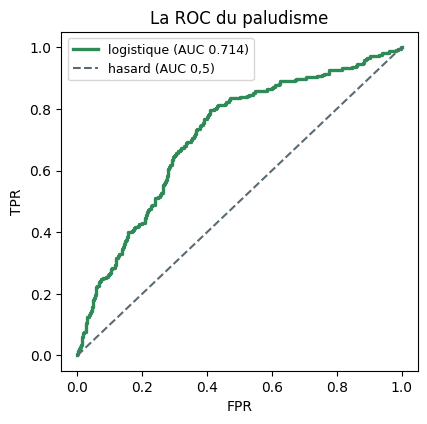

AUC = 0.714


In [24]:
# La ROC du paludisme : le verdict
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
plt.figure(figsize=(4.6, 4.4))
plt.plot(fpr, tpr, color="#2E8B57", lw=2.4, label=f"logistique (AUC {auc:.3f})")
plt.plot([0, 1], [0, 1], ls="--", color="#5A6B75", label="hasard (AUC 0,5)")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(fontsize=9)
plt.title("La ROC du paludisme"); plt.show()
print("AUC =", round(auc, 3))

**Lecture.** AUC $= 0{,}714$ : un malade tiré au hasard est classé au-dessus d'un sain
$71\,\%$ du temps. Le modèle que l'accuracy déclarait inutile **classe nettement mieux que
le hasard** — il était mal jugé, pas mauvais.

**Exercice.** Calculer l'AUC du modèle « à l'envers » en passant `1 - proba` à
`roc_auc_score`. Vérifier que les deux AUC somment à $1$, et expliquer pourquoi une AUC de
$0{,}30$ n'est pas un modèle sans valeur.

In [ ]:
# AUC de 1 - proba, et la somme des deux AUC

## Partie 7 — Le déséquilibre : rééquilibrer l'entraînement

Autre levier que le seuil : `class_weight='balanced'` repondère la log-loss pendant
l'entraînement — chaque malade pèse autant que les $\approx 7{,}5$ sains qu'il représente.

In [26]:
# class_weight='balanced' : effet sur la matrice et les métriques
modele_eq = make_pipeline(StandardScaler(),
                          LogisticRegression(max_iter=1000, random_state=0,
                                             class_weight="balanced"))
modele_eq.fit(X_train, y_train)
pred_eq = modele_eq.predict(X_test)
proba_eq = modele_eq.predict_proba(X_test)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, pred_eq).ravel()
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print("recall   :", round(tp/(tp + fn), 3))
print("accuracy :", round(accuracy_score(y_test, pred_eq), 4))
print("AUC      :", round(roc_auc_score(y_test, proba_eq), 3))

TP=187  FP=727  FN=48  TN=1038
recall   : 0.796
accuracy : 0.6125
AUC      : 0.715


**Lecture.** Recall $0{,}796$, accuracy $0{,}6125$ — quasi identique au modèle
standard pris au seuil $0{,}15$. Et l'AUC n'a pas bougé ($0{,}715$) : repondérer la perte ou
déplacer le curseur sont deux chemins vers le même compromis ; le *tri* des patients,
lui, reste le même.

In [27]:
# L'aveu C : la régularisation par défaut de LogisticRegression
for C in [0.001, 1, 1000]:
    m = make_pipeline(StandardScaler(),
                      LogisticRegression(C=C, max_iter=1000, random_state=0))
    m.fit(X_train, y_train)
    w = m.named_steps["logisticregression"].coef_[0]
    a = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    print(f"C = {C:6} : max|w| = {np.abs(w).max():.3f} · AUC = {a:.3f}")

C =  0.001 : max|w| = 0.319 · AUC = 0.715
C =      1 : max|w| = 0.750 · AUC = 0.714
C =   1000 : max|w| = 0.752 · AUC = 0.714


**Lecture.** `C` $= 1/\alpha$ : petit `C` $=$ forte pénalité (le plus grand poids
tombe de $0{,}75$ à $0{,}32$), grand `C` $=$ pénalité quasi nulle. Ici l'AUC bouge à peine
($5$ variables seulement), mais le réflexe est pris : **`C` est un réglage, pas une
constante de la nature** — son choix rigoureux est l'affaire de la Séance 7.

## Mini-défi — Régler le seuil... mais sur quelles données ?

La mission : recall $\geq 0{,}75$ avec la meilleure precision possible. Le réflexe naïf :
balayer les seuils **sur le test** et garder le meilleur. Faisons-le — puis voyons
pourquoi c'est interdit.

In [28]:
# Le réflexe naïf : choisir le seuil qui optimise la mission... sur le test
candidats = np.arange(0.05, 0.30, 0.005)
admissibles = []
for s in candidats:
    yh = (proba >= s).astype(int)
    tp = int(((yh == 1) & (y_test == 1)).sum())
    fp = int(((yh == 1) & (y_test == 0)).sum())
    fn = int(((yh == 0) & (y_test == 1)).sum())
    rec = tp/(tp + fn)
    if rec >= 0.75 and tp + fp > 0:
        admissibles.append((s, tp/(tp + fp), rec))
meilleur = max(admissibles, key=lambda t: t[1])
print("seuil optimal trouvé sur le test :", round(meilleur[0], 3))
print("precision :", round(meilleur[1], 3), "· recall :", round(meilleur[2], 3))

seuil optimal trouvé sur le test : 0.145
precision : 0.205 · recall : 0.791


In [29]:
# Le même réglage, fait proprement : sur une tranche de validation
X_app, X_val, y_app, y_val = train_test_split(X_train, y_train, test_size=0.25,
                                              random_state=0, stratify=y_train)
m = make_pipeline(StandardScaler(),
                  LogisticRegression(max_iter=1000, random_state=0)).fit(X_app, y_app)
proba_val = m.predict_proba(X_val)[:, 1]
adm = []
for s in candidats:
    yh = (proba_val >= s).astype(int)
    tp = int(((yh == 1) & (y_val == 1)).sum())
    fp = int(((yh == 1) & (y_val == 0)).sum())
    fn = int(((yh == 0) & (y_val == 1)).sum())
    rec = tp/(tp + fn)
    if rec >= 0.75 and tp + fp > 0:
        adm.append((s, tp/(tp + fp)))
seuil_propre = max(adm, key=lambda t: t[1])[0]
print("seuil choisi sur la validation :", round(seuil_propre, 3))

# Verdict final, une seule fois, sur le test
yh = (m.predict_proba(X_test)[:, 1] >= seuil_propre).astype(int)
tp = int(((yh == 1) & (y_test == 1)).sum()); fp = int(((yh == 1) & (y_test == 0)).sum())
fn = int(((yh == 0) & (y_test == 1)).sum())
print(f"sur le test : precision = {tp/(tp+fp):.3f} · recall = {tp/(tp+fn):.3f}")

seuil choisi sur la validation : 0.06
sur le test : precision = 0.178 · recall = 0.843


**Lecture.** Le seuil choisi *en regardant le test* affiche forcément le plus beau
chiffre possible — c'est la **fuite** de la Séance 4, version hyperparamètre : le test a
servi de terrain d'entraînement au réglage, son verdict ne vaut plus rien. La version
propre réserve une tranche de **validation** pour régler, et ne touche au test qu'une
fois, à la fin.

Mais cette tranche de validation pose ses propres questions : elle ampute
l'entraînement, et son verdict dépend du hasard du découpage. Régler `C`, le seuil — et
demain la profondeur d'un arbre — réclame un protocole plus solide : la **validation
croisée**, objet de la **Séance 7**.

## Synthèse — à compléter

1. La régression logistique passe le score linéaire dans la **..........**, qui en fait
   une **..........** ; elle s'entraîne en minimisant la **..........** par descente de
   gradient.
2. La matrice de confusion compte **..........** cases ; la precision juge les
   **..........**, le recall juge les **..........**.
3. Baisser le seuil fait monter le **..........** et baisser la **..........** ; le seuil
   se choisit selon la **..........**, jamais par défaut.
4. L'AUC est la probabilité de bien ordonner une paire (**..........**, **..........**) ;
   elle ne dépend d'aucun **..........**.
5. Sur une classe rare, l'accuracy doit toujours être comparée à la **..........**
   majoritaire ; seuil et `C` sont des **..........** et se règlent sur la
   **..........**, pas sur le test.